# 1050 nm Registered ROI Pipeline Demo

This notebook is a small worked example for the shared Fucci ROI pipeline.
It uses the 1050 nm dataset, runs the shared computation steps in notebook cells,
and renders only a few top-ranked ROIs so you have a clean place to continue exploring.

Recommended mask for this demo: `mean_image_merge_cp_masks_SAM.tif`.


In [1]:
from __future__ import annotations

from dataclasses import asdict
from datetime import datetime
from pathlib import Path

import pandas as pd
import tifffile
from IPython.display import Image, Markdown, display

from analysis_paths import get_dataset_analysis_dir, resolve_dataset_dir
from roi_log_ratio_analysis import (
    add_day0_normalized_column,
    apply_channel_dark_correction,
    attach_roi_size_metrics,
    build_registered_image_lookup,
    compute_green_red_fit_residuals,
    compute_log_ratio_metrics,
    compute_roi_size_table,
    estimate_size_filter_bounds,
    extract_registered_dataset_roi_intensity_table,
    filter_complete_rois,
    flag_shape_qc_rois,
    select_ranked_roi_days,
    select_top_changing_rois,
    summarize_daily_green_red_linear_fits,
    summarize_residual_sign_changes,
    summarize_roi_metrics,
    wide_table_from_long_table,
)
from run_registered_roi_pipeline import RegisteredPipelineConfig, render_registered_roi_panel

config = RegisteredPipelineConfig(
    dataset='1050',
    start_date='20260511',
    mask_name='mean_image_merge_cp_masks_SAM.tif',
    green_dark=319.0,
    red_dark=534.0,
    max_top_rois=3,
)

dataset_dir = resolve_dataset_dir(config.dataset)
analysis_dir = get_dataset_analysis_dir(config.dataset)
demo_output_dir = analysis_dir / f"demo_registered_roi_pipeline_1050_{datetime.now():%Y%m%d_%H%M%S}"
demo_output_dir.mkdir(parents=True, exist_ok=False)
mask_path = dataset_dir / config.mask_name
mask_stack = tifffile.imread(mask_path)

print(f'dataset_dir={dataset_dir}')
print(f'demo_output_dir={demo_output_dir}')


dataset_dir=/mnt/d/_data/_newAAV_2026/Fucci-Tri_avg_images/1050_data
demo_output_dir=/mnt/d/_data/_newAAV_2026/Fucci-Tri_avg_images/1050_data/analysis/demo_registered_roi_pipeline_1050_20260529_154035


In [2]:
raw_roi_table = extract_registered_dataset_roi_intensity_table(
    image_dir=dataset_dir,
    mask_path=mask_path,
    start_date=config.start_date,
)
corrected_roi_table = apply_channel_dark_correction(
    intensity_table=raw_roi_table,
    green_dark=config.green_dark,
    red_dark=config.red_dark,
    intensity_column='mean_intensity',
    corrected_column='mean_intensity_corrected',
    clip_floor=None,
)
roi_day_table = wide_table_from_long_table(
    corrected_roi_table,
    intensity_column='mean_intensity_corrected',
    start_date=config.start_date,
)
complete_roi_day_table = filter_complete_rois(roi_day_table)
roi_metrics = compute_log_ratio_metrics(complete_roi_day_table, epsilon=config.epsilon)

roi_size_table = compute_roi_size_table(
    mask_stack=mask_stack,
    xy_um_per_px=config.xy_um_per_px,
    z_um_per_plane=config.z_um_per_plane,
)
size_bounds = estimate_size_filter_bounds(roi_size_table, area_column='proj_area_px')
roi_size_table['size_qc_pass'] = roi_size_table['proj_area_px'].between(
    size_bounds['lower_bound'],
    size_bounds['upper_bound'],
    inclusive='both',
)
roi_size_table = flag_shape_qc_rois(roi_size_table)

metrics_with_size = roi_metrics.merge(roi_size_table, on='roi_id', how='left', validate='many_to_one')
metrics_size_shape_filtered = metrics_with_size.loc[
    metrics_with_size['size_qc_pass'] & metrics_with_size['shape_qc_pass']
].copy()

print(f'mask ROIs: {roi_size_table["roi_id"].nunique()}')
print(f'complete ROIs: {complete_roi_day_table["roi_id"].nunique()}')
print(f'size + shape filtered ROIs: {metrics_size_shape_filtered["roi_id"].nunique()}')


mask ROIs: 5935
complete ROIs: 5864
size + shape filtered ROIs: 4972


In [3]:
roi_summary = summarize_roi_metrics(metrics_size_shape_filtered)
roi_summary = attach_roi_size_metrics(roi_summary, roi_size_table)
fit_summary = summarize_daily_green_red_linear_fits(metrics_size_shape_filtered)
residual_table = compute_green_red_fit_residuals(
    roi_metrics=metrics_size_shape_filtered,
    fit_summary=fit_summary,
)
residual_summary = summarize_residual_sign_changes(residual_table)
roi_metrics_with_residuals = residual_table.merge(
    residual_summary,
    on='roi_id',
    how='left',
    validate='many_to_one',
)

top_decreasing = select_top_changing_rois(
    roi_summary=roi_summary,
    max_rois=3,
    red_cv_max=config.red_cv_max,
    min_day0_brightness_quantile=config.min_day0_brightness_quantile,
    direction='decreasing',
)
top_increasing = select_top_changing_rois(
    roi_summary=roi_summary,
    max_rois=3,
    red_cv_max=config.red_cv_max,
    min_day0_brightness_quantile=config.min_day0_brightness_quantile,
    direction='increasing',
)

display(Markdown('## Top decreasing ROIs'))
display(top_decreasing[[
    'selection_rank', 'roi_id', 'min_delta_log2_green_over_red', 'red_cv',
    'proj_area_px', 'circularity', 'solidity', 'axis_ratio'
]])
display(Markdown('## Top increasing ROIs'))
display(top_increasing[[
    'selection_rank', 'roi_id', 'max_delta_log2_green_over_red', 'red_cv',
    'proj_area_px', 'circularity', 'solidity', 'axis_ratio'
]])


## Top decreasing ROIs

,selection_rank,roi_id,min_delta_log2_green_over_red,red_cv,proj_area_px,circularity,solidity,axis_ratio
0,1,2270,-1.612903,0.070602,169,0.918187,0.971264,1.460789
1,2,2688,-1.302527,0.047976,163,0.889109,0.920904,1.215576
2,3,616,-1.158833,0.047362,236,0.933387,0.955466,1.414453


## Top increasing ROIs

,selection_rank,roi_id,max_delta_log2_green_over_red,red_cv,proj_area_px,circularity,solidity,axis_ratio
0,1,852,3.789933,0.069648,43,0.699626,0.895833,1.271299
1,2,1289,1.281472,0.063361,195,0.902221,0.960591,1.138503
2,3,2795,0.716997,0.094570,287,0.970982,0.959866,1.048037


## Decreasing ROI panels

rank_01_roi_2270.png

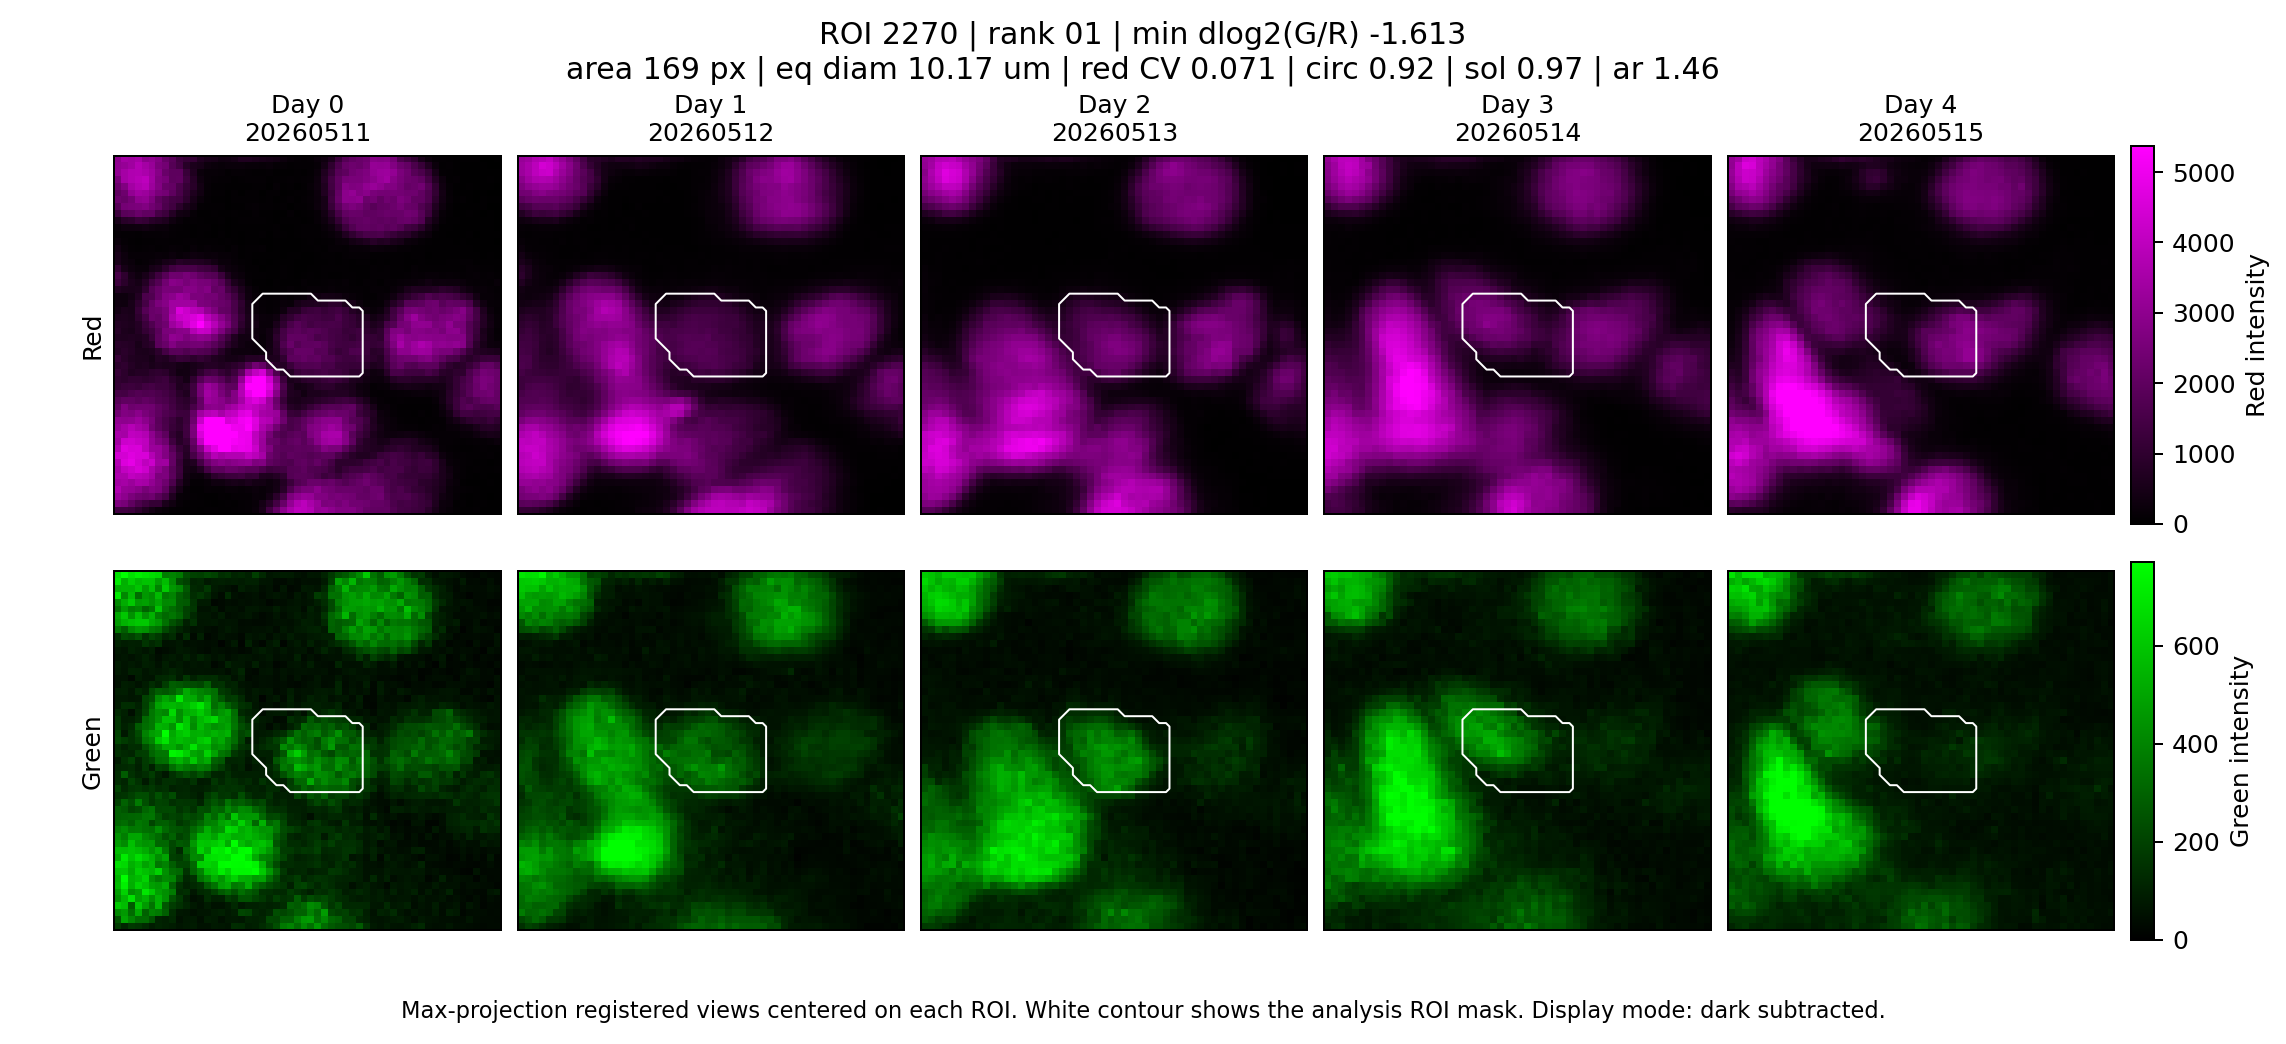

rank_02_roi_2688.png

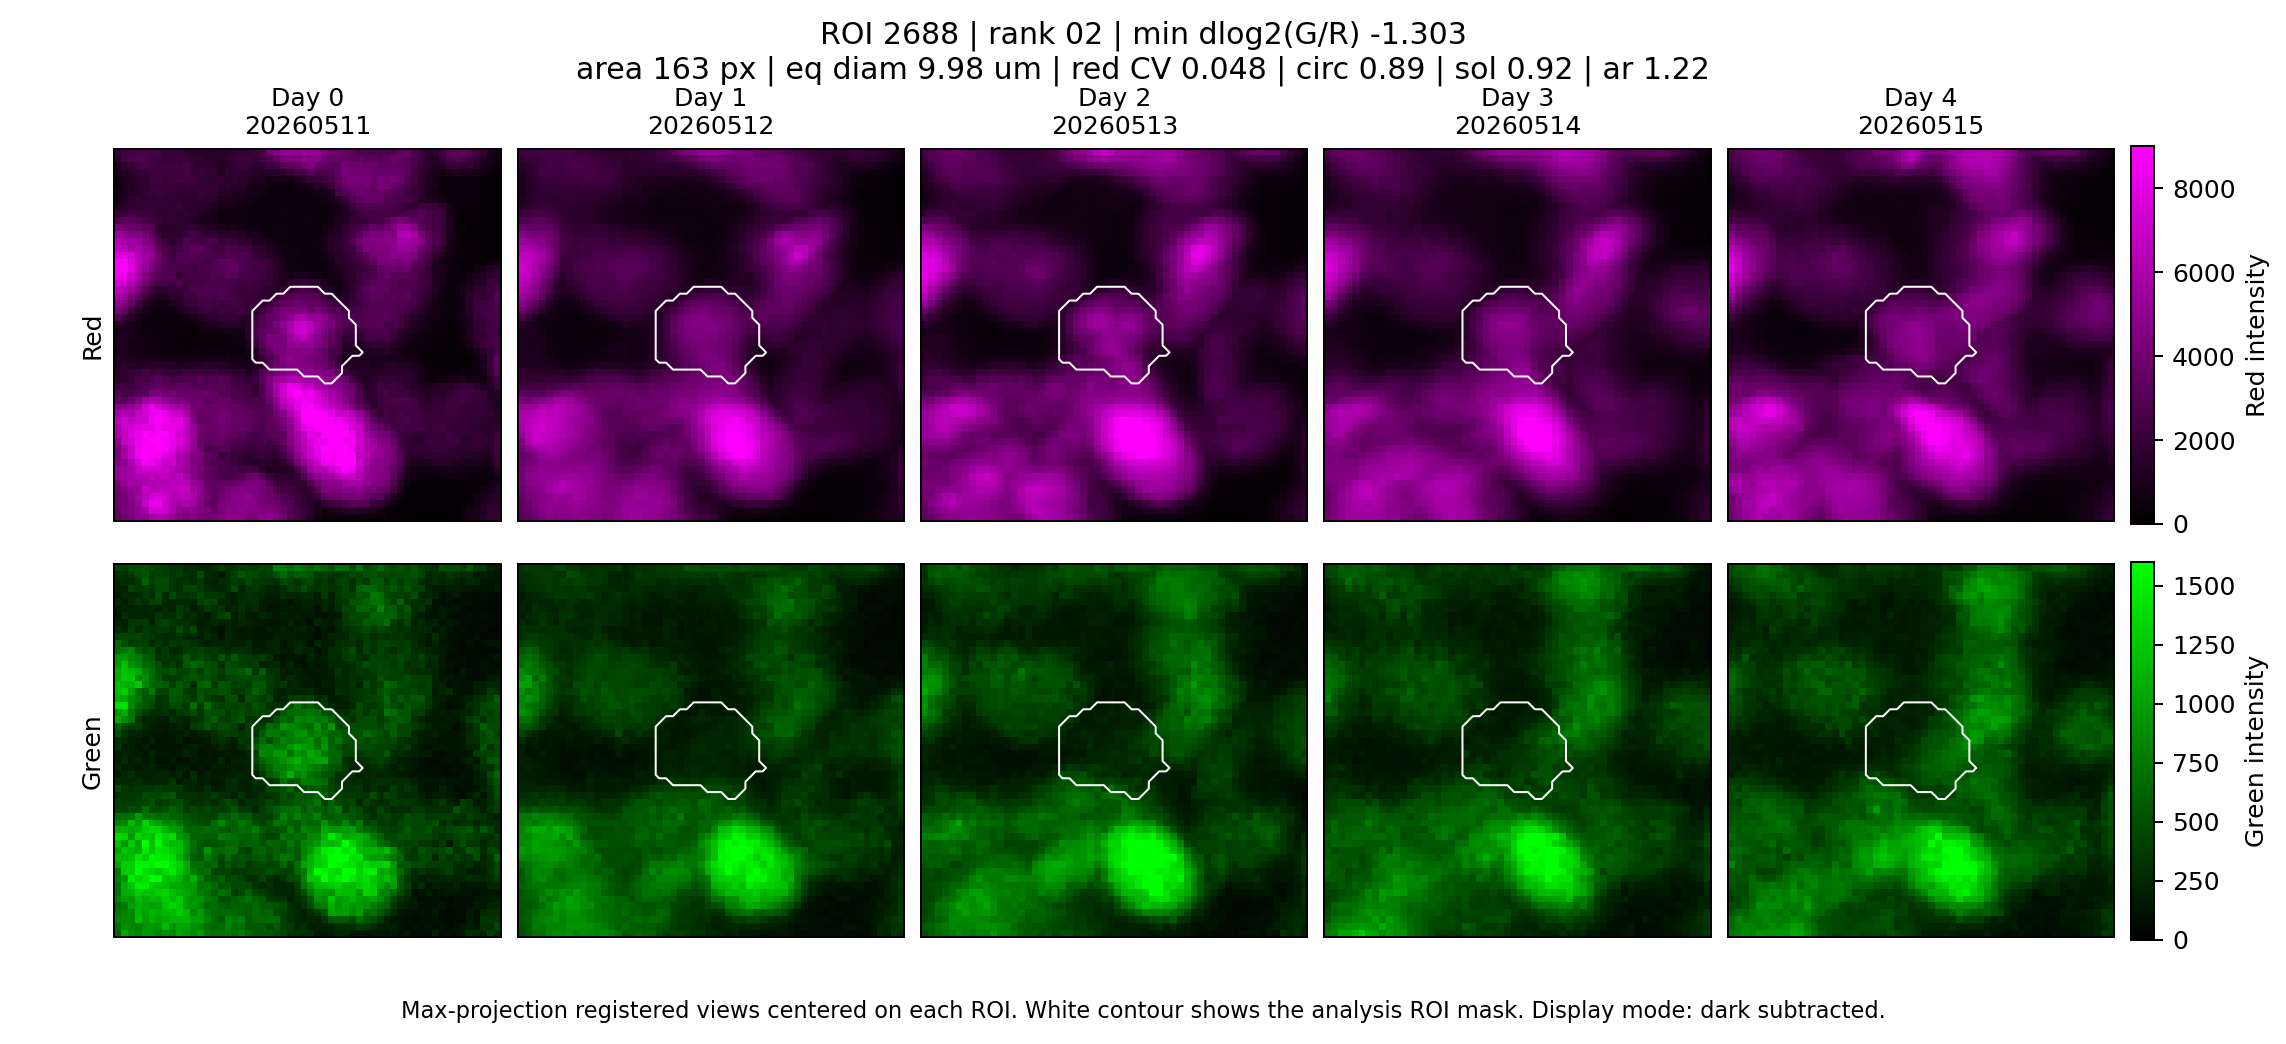

rank_03_roi_616.png

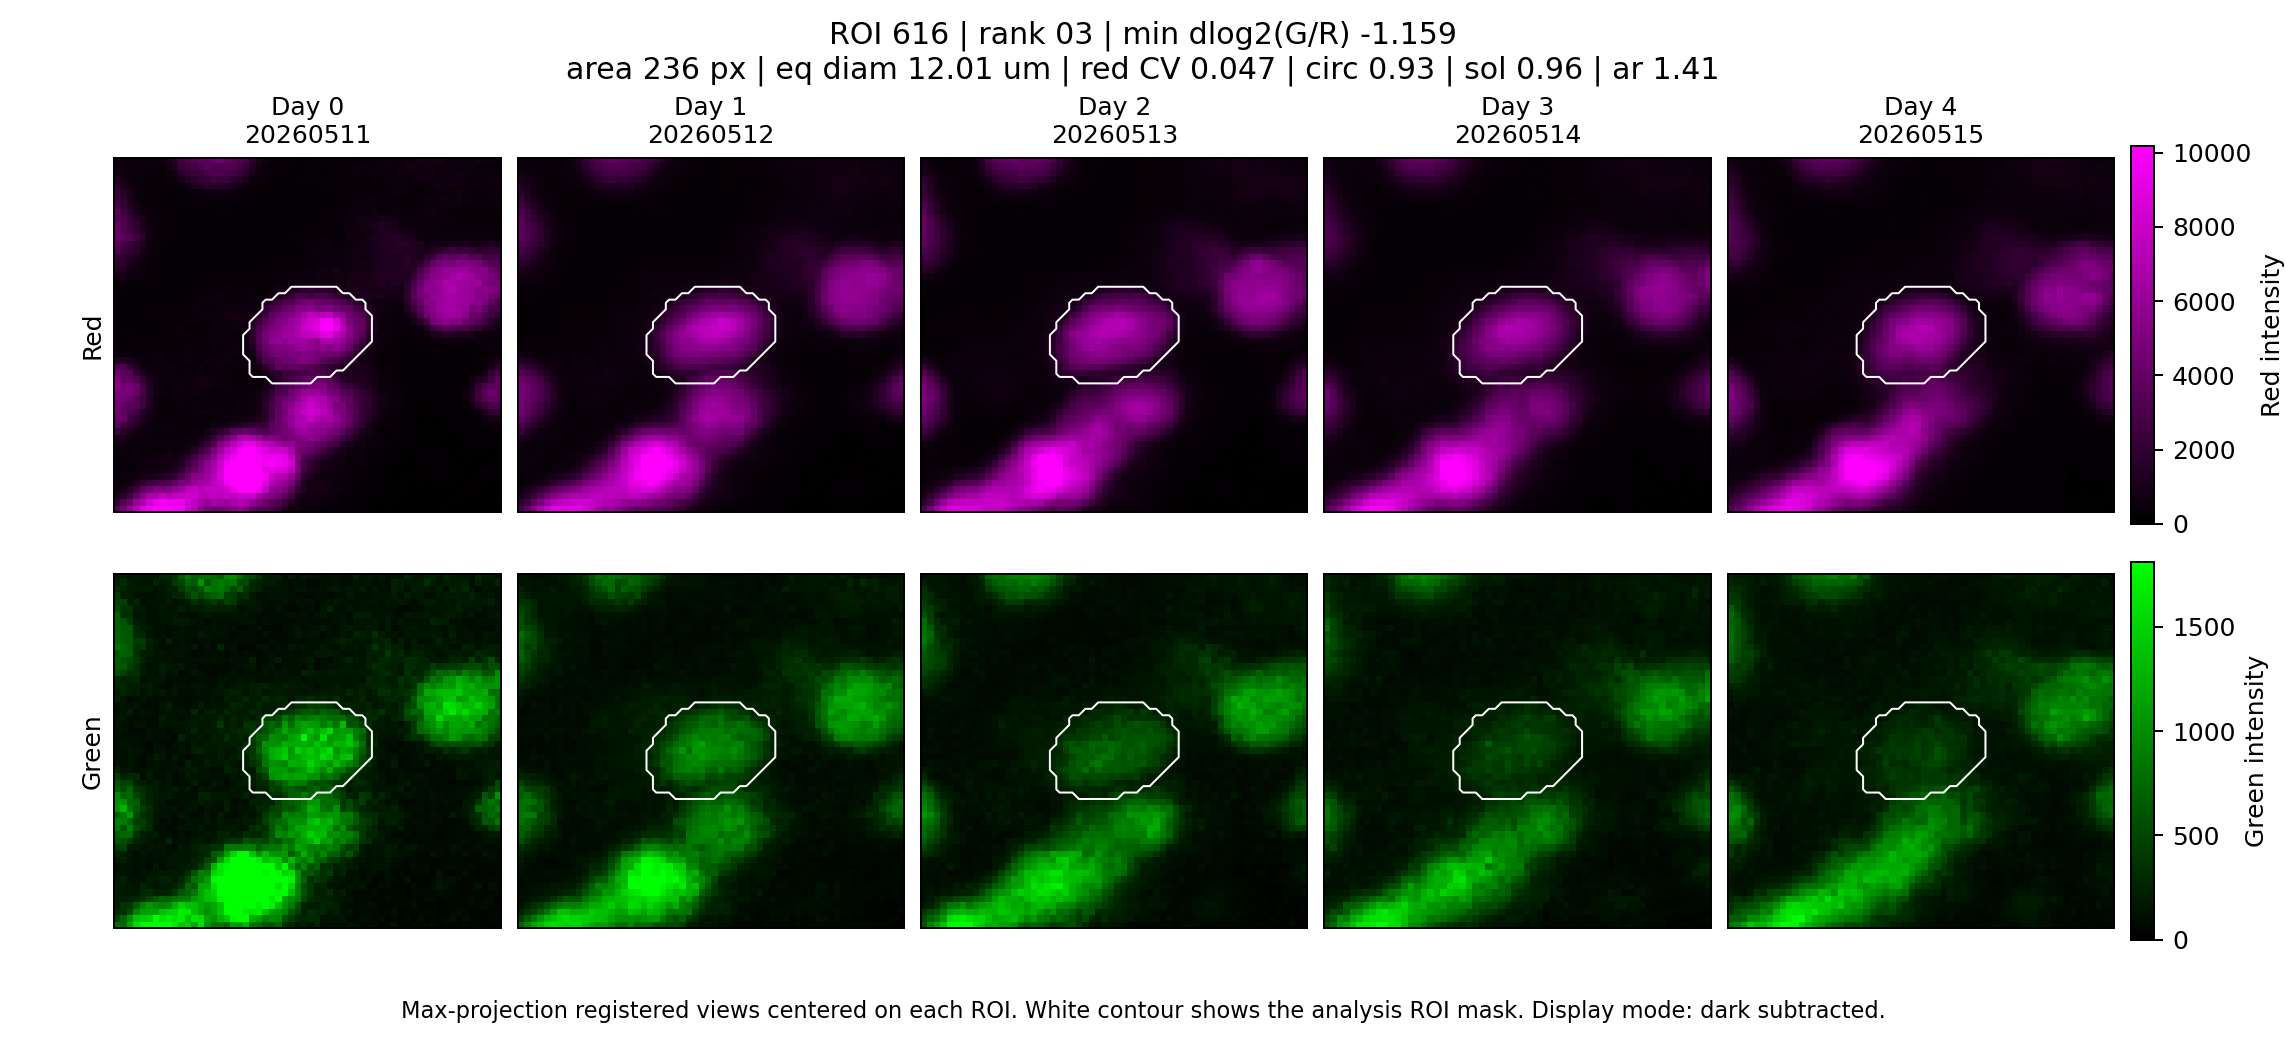

## Increasing ROI panels

rank_01_roi_852.png

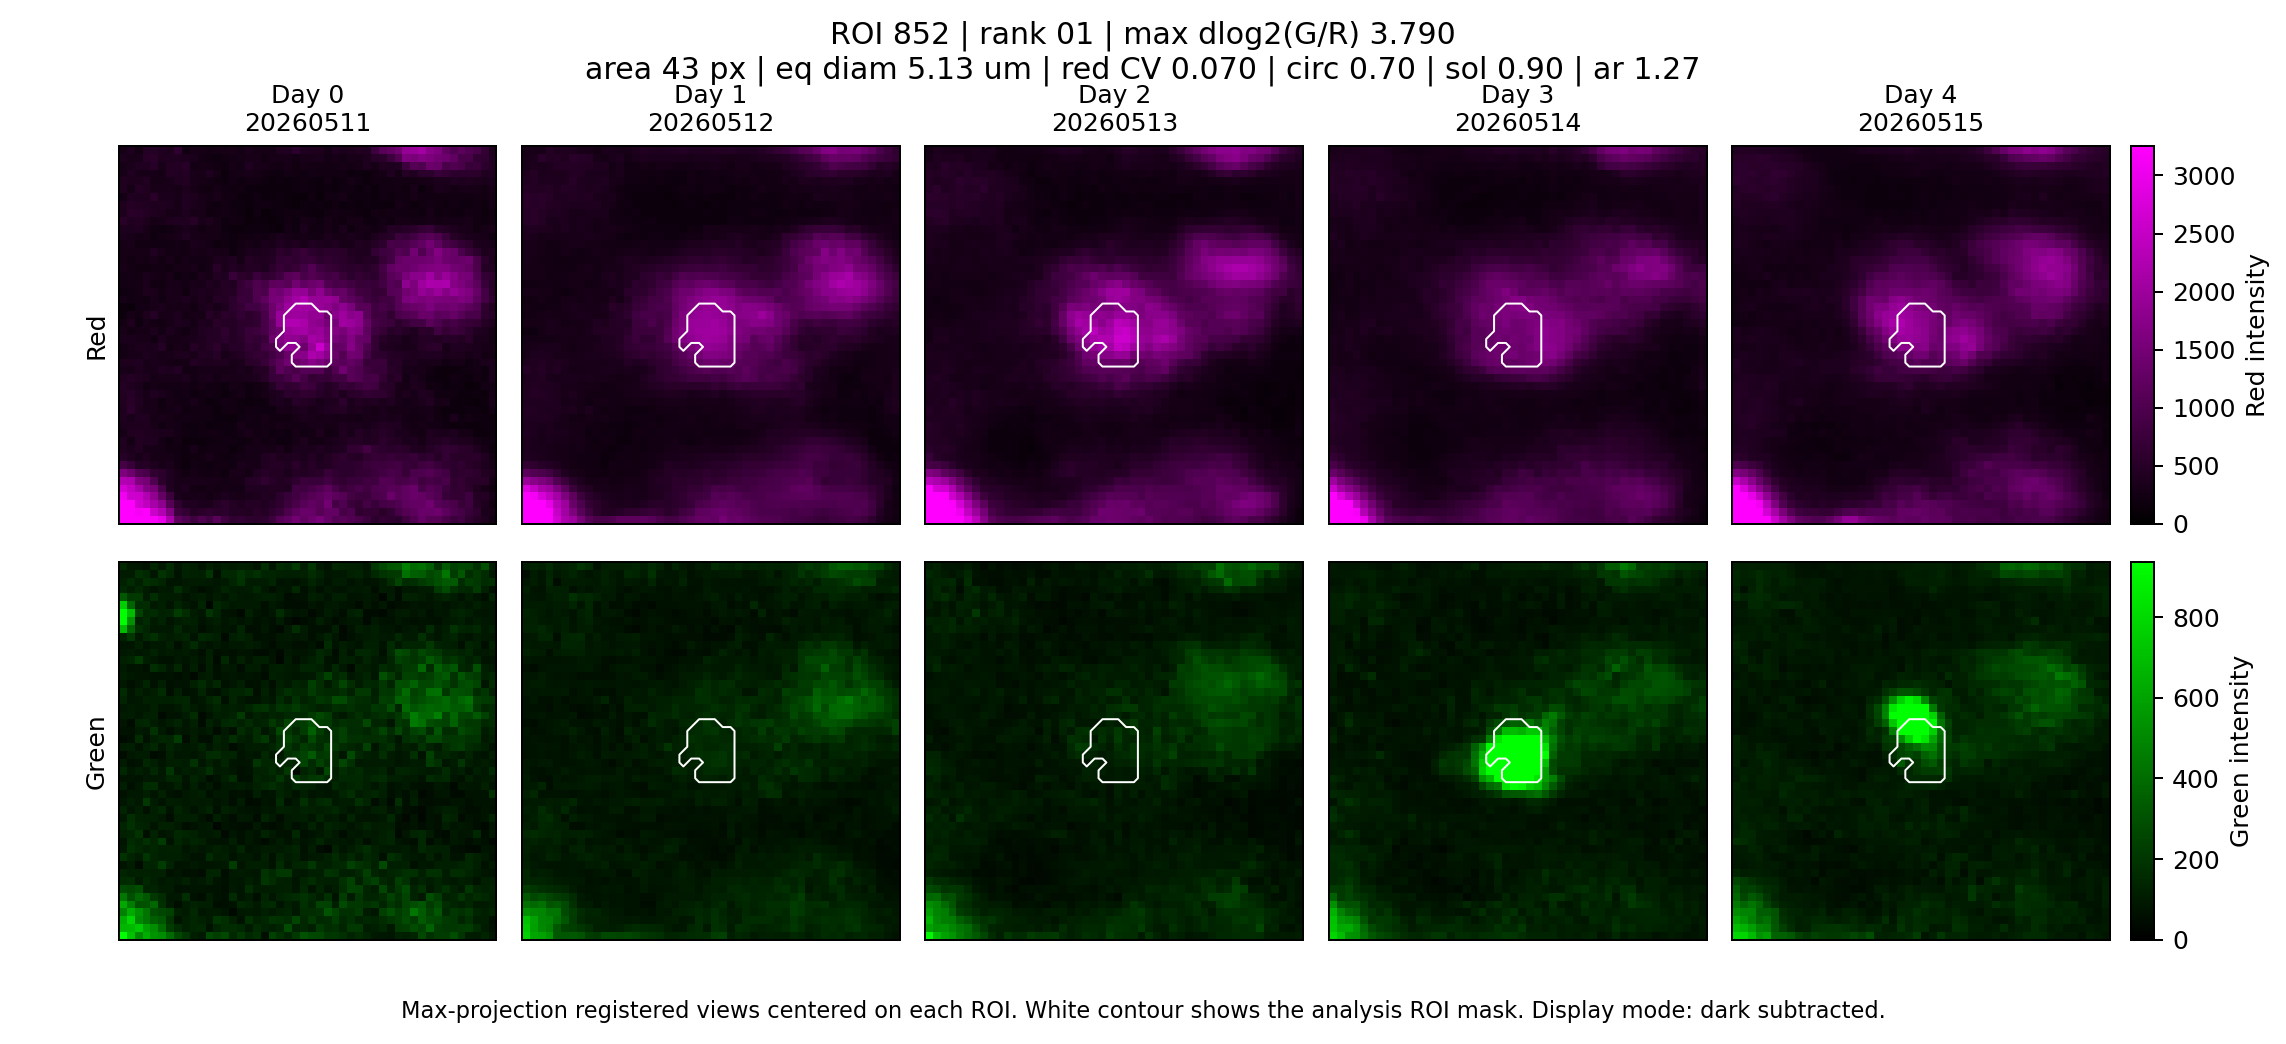

rank_02_roi_1289.png

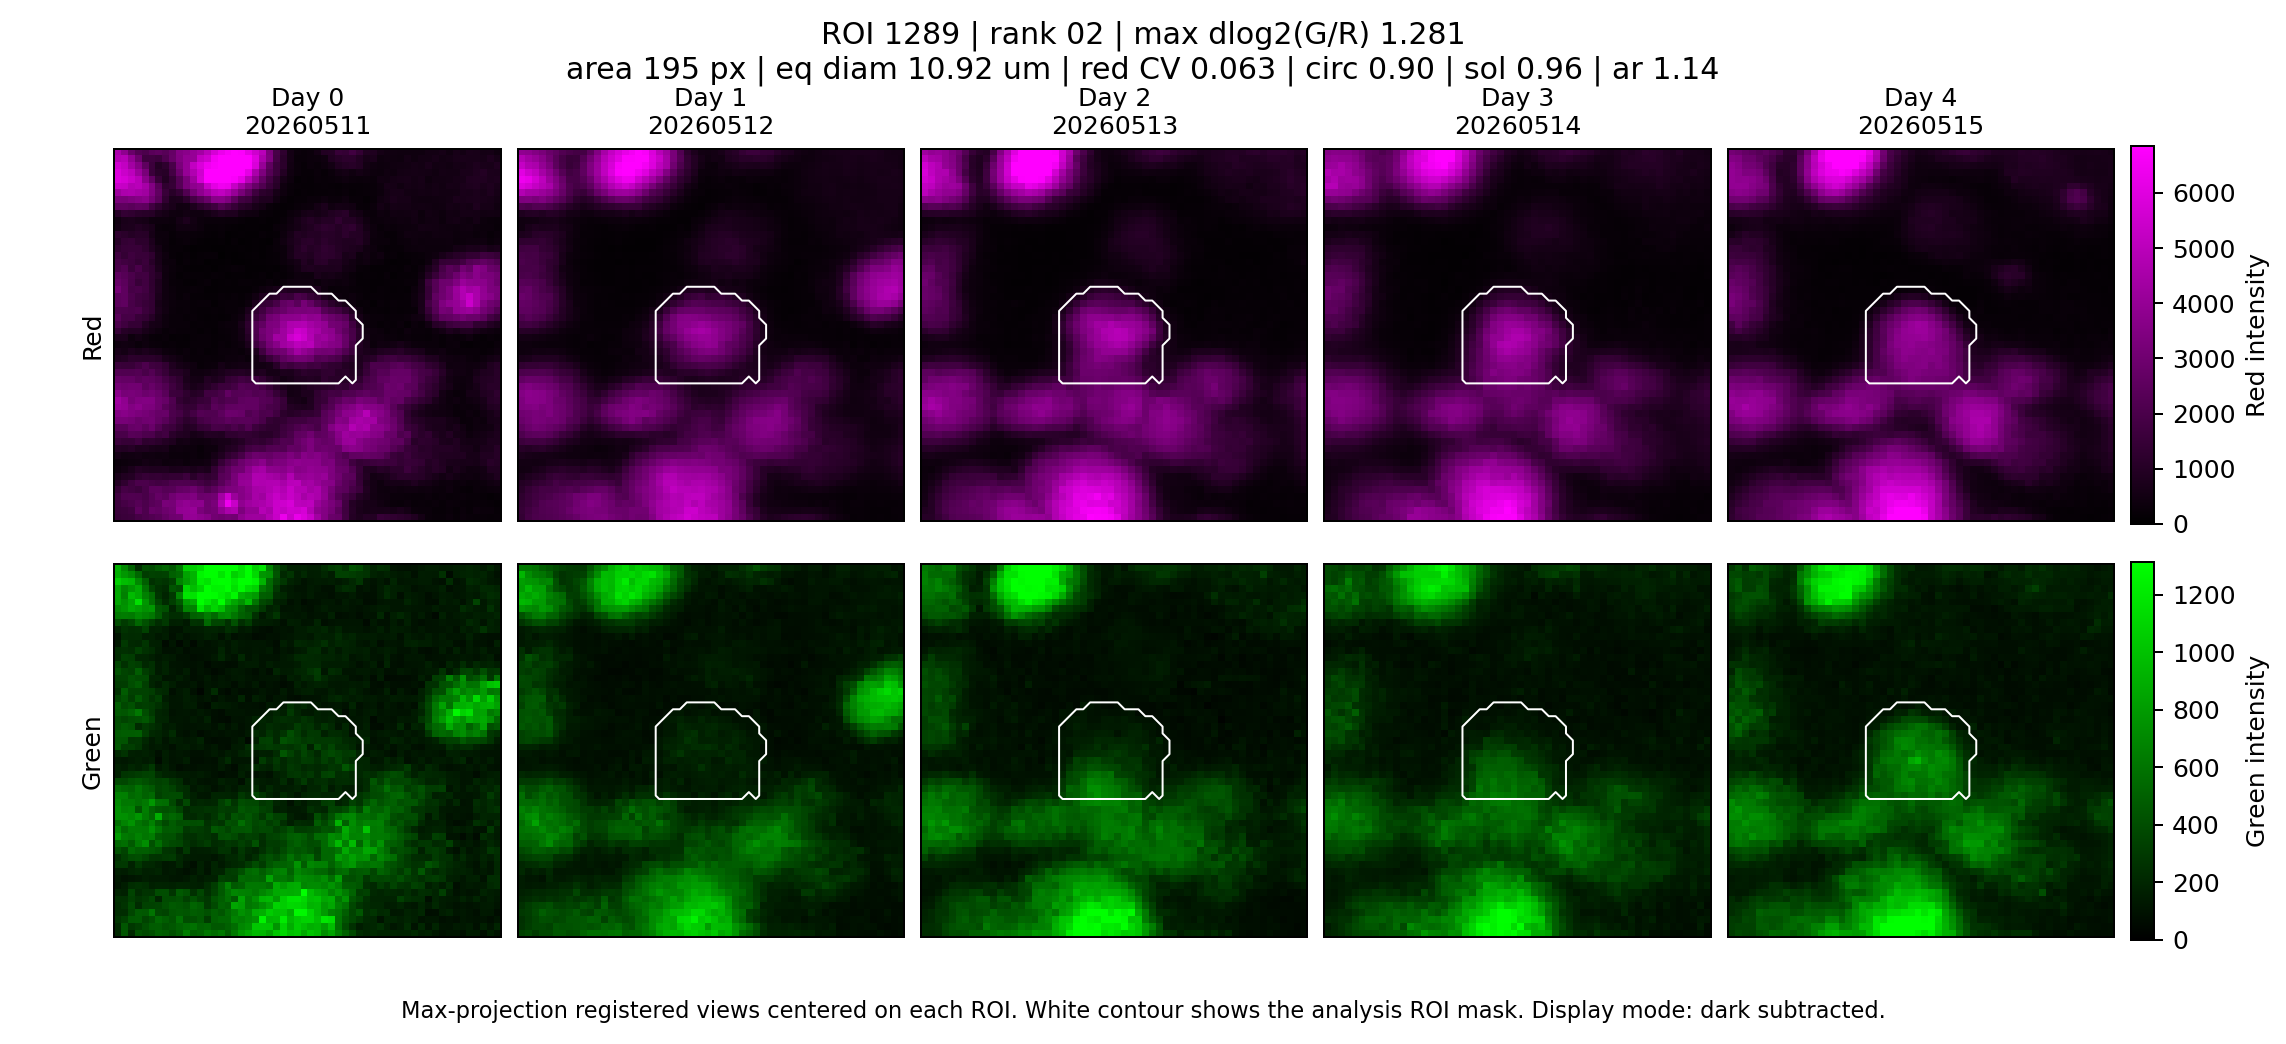

rank_03_roi_2795.png

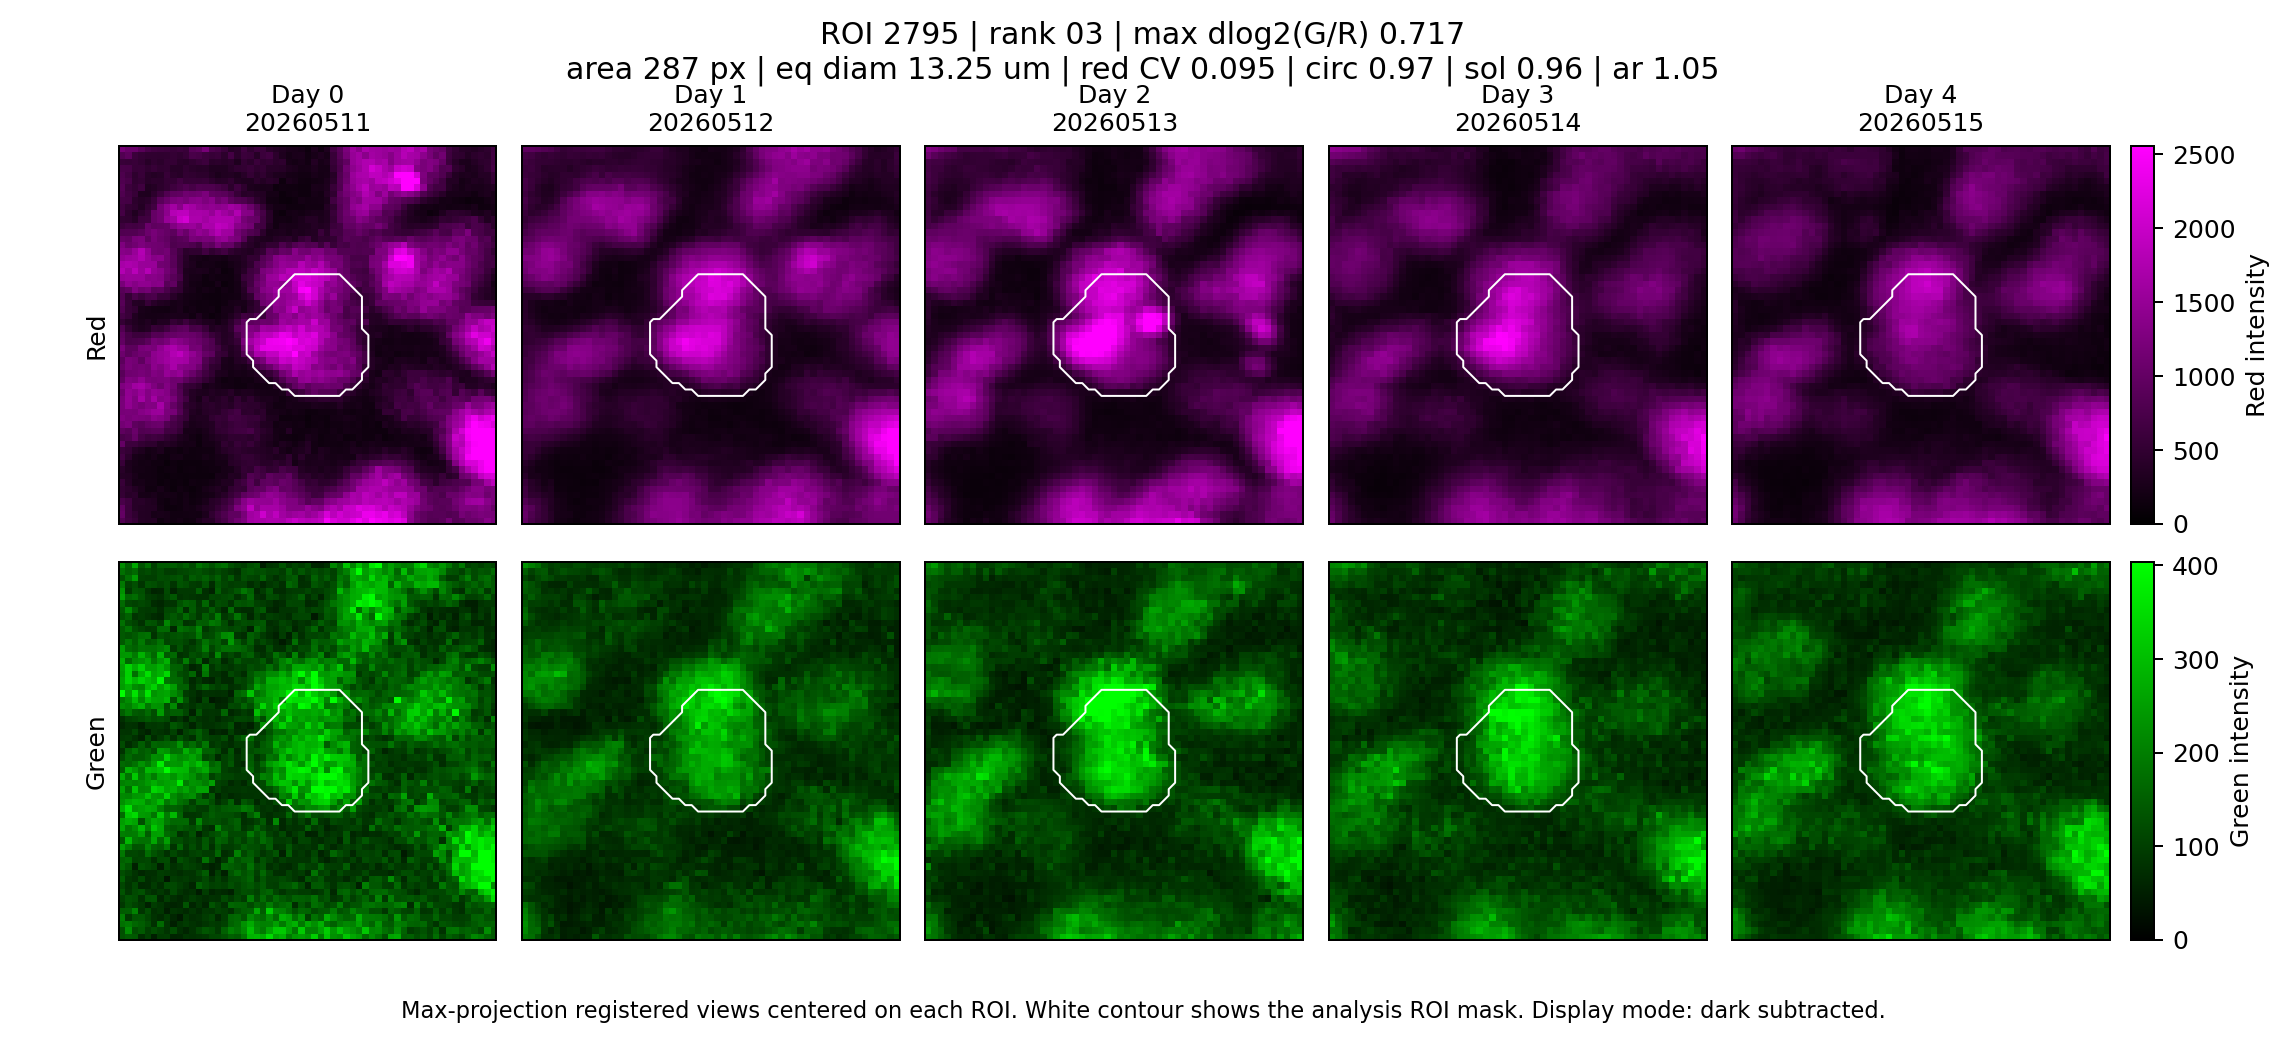

In [4]:
registered_lookup = build_registered_image_lookup(dataset_dir, start_date=config.start_date)
image_cache = {key: tifffile.imread(path).astype(float) for key, path in sorted(registered_lookup.items())}

def render_example_panels(top_roi_table: pd.DataFrame, direction_label: str, display_mode: str = 'dark_subtracted') -> list[Path]:
    output_dir = demo_output_dir / f'{direction_label}_{display_mode}_panels'
    output_dir.mkdir(parents=True, exist_ok=True)
    panel_paths: list[Path] = []
    for _, roi_row in top_roi_table.iterrows():
        panel_path = output_dir / f"rank_{int(roi_row['selection_rank']):02d}_roi_{int(roi_row['roi_id'])}.png"
        render_registered_roi_panel(
            roi_row=roi_row,
            image_cache=image_cache,
            mask_stack=mask_stack,
            output_path=panel_path,
            start_date=config.start_date,
            direction_label=direction_label,
            display_mode=display_mode,
            green_dark=config.green_dark,
            red_dark=config.red_dark,
            pad_xy=config.pad_xy,
            min_crop_size=config.min_crop_size,
        )
        panel_paths.append(panel_path)
    return panel_paths

decreasing_panel_paths = render_example_panels(top_decreasing, 'decreasing')
increasing_panel_paths = render_example_panels(top_increasing, 'increasing')

for label, paths in [('Decreasing', decreasing_panel_paths), ('Increasing', increasing_panel_paths)]:
    display(Markdown(f'## {label} ROI panels'))
    for path in paths:
        display(Markdown(path.name))
        display(Image(filename=str(path)))


## Next steps

- To run the full saved-output pipeline, use [run_registered_roi_pipeline.py](/mnt/d/_data/_newAAV_2026/Fucci-Tri_avg_images/run_registered_roi_pipeline.py).
- To validate registration against raw images when inverse masks exist, use the optional raw-space validation in the shared pipeline.
- If you want to explore a different mask, change only `config.mask_name` and rerun the notebook cells.
